# Решение задания

В этом Jupyter Notebook я проведу анализ датасета Steam Video Games, включая загрузку данных, их анализ, очистку, построение предсказательной модели и выводы для бизнес-применения.

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

In [ ]:
from lightgbm import LGBMRegressor

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
sns.set(style="whitegrid")

# Загрузка данных
df = pd.read_csv('/content/drive/MyDrive/steam_data_with_metrics.csv')

# Разделение данных на покупки и игровое время
print(df.head())
df['purchase'] = (df['behavior-name'] == 'purchase').astype(int)
df['play'] = (df['behavior-name'] == 'play').astype(int)
df.drop(labels='placeholder', axis=1, inplace=True)
df.drop(labels='behavior-name', axis=1, inplace=True)

     user-id                  game-title behavior-name  value  placeholder  \
0  151603712  The Elder Scrolls V Skyrim          play  273.0            0   
1  151603712                   Fallout 4      purchase    1.0            0   
2  151603712                   Fallout 4          play   87.0            0   
3  151603712                       Spore      purchase    1.0            0   
4  151603712                       Spore          play   14.9            0   

  price publisher type base-game  
0   NaN       NaN  NaN       NaN  
1   NaN       NaN  NaN       NaN  
2   NaN       NaN  NaN       NaN  
3   NaN       NaN  NaN       NaN  
4   NaN       NaN  NaN       NaN  


## 1. Анализ данных

In [10]:
print(df.head())
print(df.info())
print(df.isnull().sum())

     user-id                  game-title  value price publisher type  \
0  151603712  The Elder Scrolls V Skyrim  273.0   NaN       NaN  NaN   
1  151603712                   Fallout 4    1.0   NaN       NaN  NaN   
2  151603712                   Fallout 4   87.0   NaN       NaN  NaN   
3  151603712                       Spore    1.0   NaN       NaN  NaN   
4  151603712                       Spore   14.9   NaN       NaN  NaN   

  base-game  purchase  play  
0       NaN         0     1  
1       NaN         1     0  
2       NaN         0     1  
3       NaN         1     0  
4       NaN         0     1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205261 entries, 0 to 205260
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user-id     205261 non-null  int64  
 1   game-title  205261 non-null  object 
 2   value       205261 non-null  float64
 3   price       50572 non-null   object 
 4   publisher   49787 no


  - Пропущенные значения в `price`, `publisher`, `type`, `base-game` существуют из-за ограничений Steam API. Так как в колонке `base-game` набралось слишком мало значений, то выкинем её.

In [11]:
df.drop(labels='base-game', axis=1, inplace=True)

### Небольшая предобработка

In [12]:
df['price'] = df['price'].replace('Бесплатно', '0').str.replace('[$]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

cleaned_df = df.dropna()
df['price'].fillna(df['price'].median(), inplace=True)
df['publisher'].fillna('Unknown', inplace=True)
df['type'].fillna('Игра', inplace=True)

/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3473: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  if (await self.run_code(code, result,  async_=asy)):


### Визуальный анализ

Выведем две матрицы корреляции: для датасета c удаленными NaN и с заполненными пропусками.

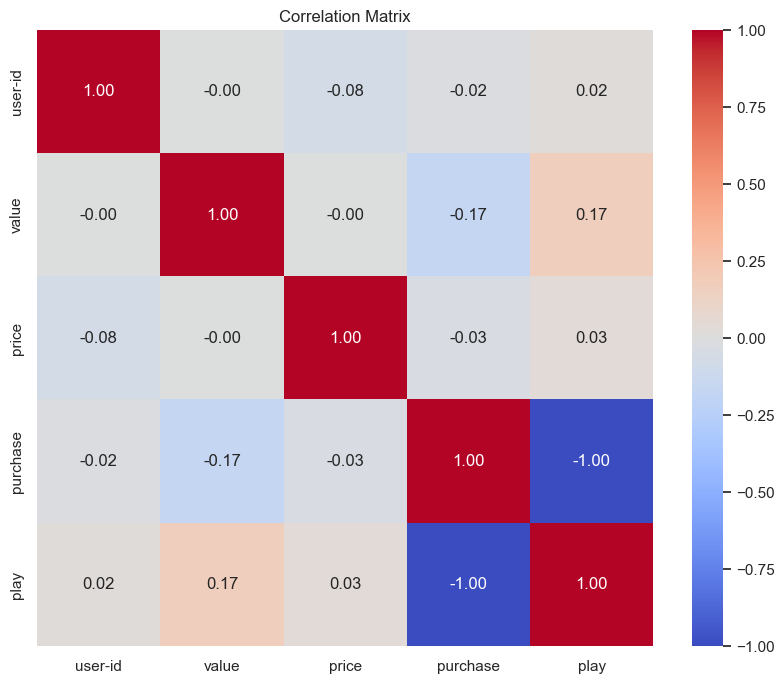

In [ ]:
corr_matrix = df.corr(numeric_only=True)

# Построение тепловой карты (heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix')
plt.show()

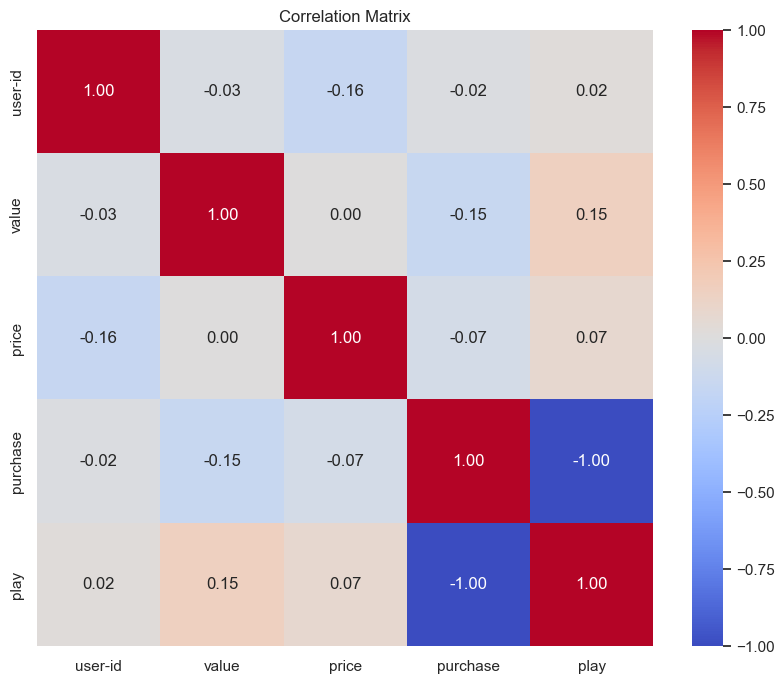

In [ ]:
corr_matrix = cleaned_df.corr(numeric_only=True)

# Построение тепловой карты (heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
print(df.head())

     user-id                  game-title  value  price publisher  type  \
0  151603712  The Elder Scrolls V Skyrim  273.0   1.99   Unknown  Игра   
1  151603712                   Fallout 4    1.0   1.99   Unknown  Игра   
2  151603712                   Fallout 4   87.0   1.99   Unknown  Игра   
3  151603712                       Spore    1.0   1.99   Unknown  Игра   
4  151603712                       Spore   14.9   1.99   Unknown  Игра   

   purchase  play  
0         0     1  
1         1     0  
2         0     1  
3         1     0  
4         0     1  


**Топ-10 издателей по числу уникальных игр**

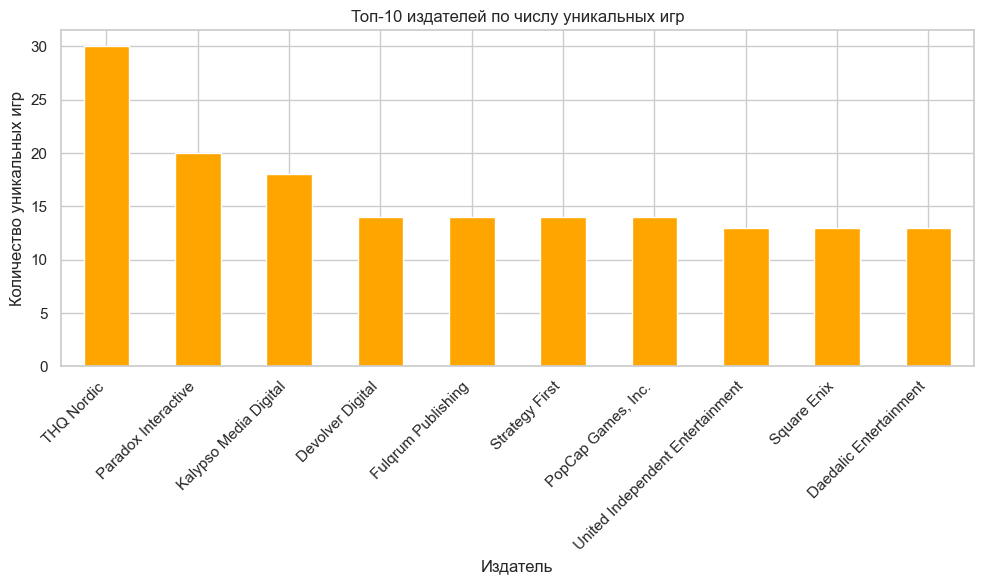

In [ ]:
top_publishers = cleaned_df.groupby('publisher')['game-title'].nunique().sort_values(ascending=False).head(10)

# Строим график
plt.figure(figsize=(10, 6))
top_publishers.plot(kind='bar', color='orange', title='Топ-10 издателей по числу уникальных игр')
plt.ylabel('Количество уникальных игр')
plt.xlabel('Издатель')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Топ-10 игр по количеству покупок**

C:\Users\ПК\AppData\Local\Temp\ipykernel_19232\365698590.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_purchases.values, y=top_purchases.index, palette="Blues_d")


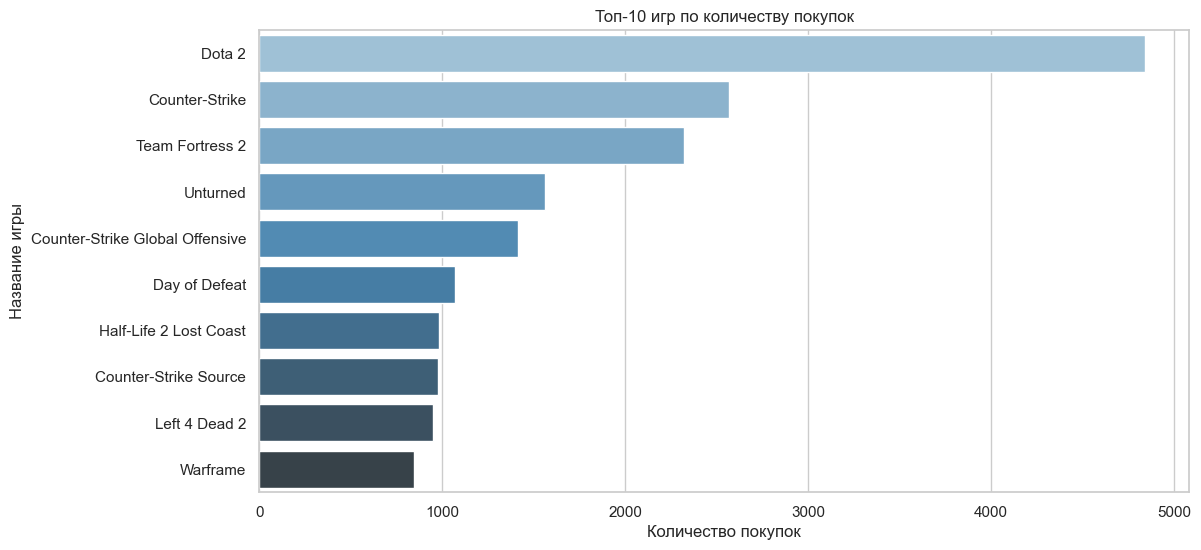

In [ ]:
plt.figure(figsize=(12, 6))
top_purchases = df[df['purchase'] == 1]['game-title'].value_counts().head(10)
sns.barplot(x=top_purchases.values, y=top_purchases.index, palette="Blues_d")
plt.title('Топ-10 игр по количеству покупок')
plt.xlabel('Количество покупок')
plt.ylabel('Название игры')
plt.show()

**Топ-10 игр по общему времени игры**

C:\Users\ПК\AppData\Local\Temp\ipykernel_19232\282333475.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_plays.values, y=top_plays.index, palette="Greens_d")


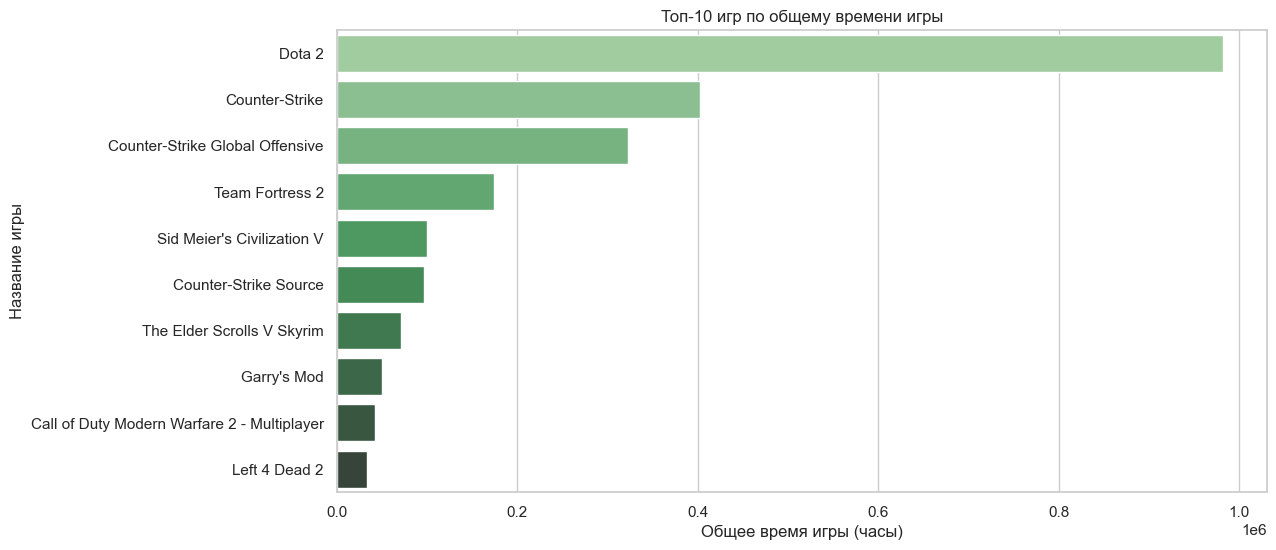

In [ ]:
plt.figure(figsize=(12, 6))
top_plays = df[df['play'] == 1].groupby('game-title')['value'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_plays.values, y=top_plays.index, palette="Greens_d")
plt.title('Топ-10 игр по общему времени игры')
plt.xlabel('Общее время игры (часы)')
plt.ylabel('Название игры')
plt.show()

**Распределение времени игры**

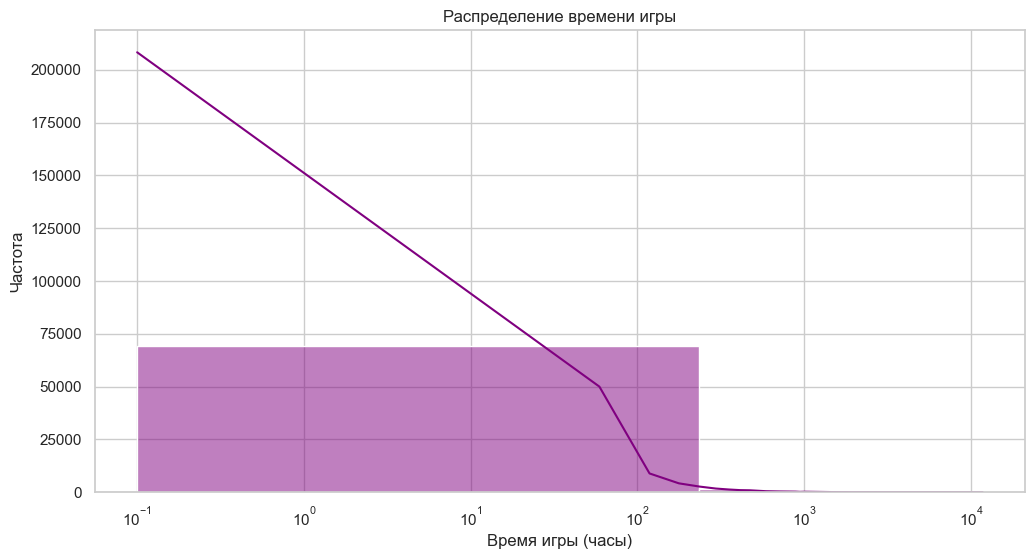

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df[df['play'] == 1]['value'], bins=50, kde=True, color='purple')
plt.title('Распределение времени игры')
plt.xlabel('Время игры (часы)')
plt.ylabel('Частота')
plt.xscale('log')
plt.show()

**Распределение цен на игры**

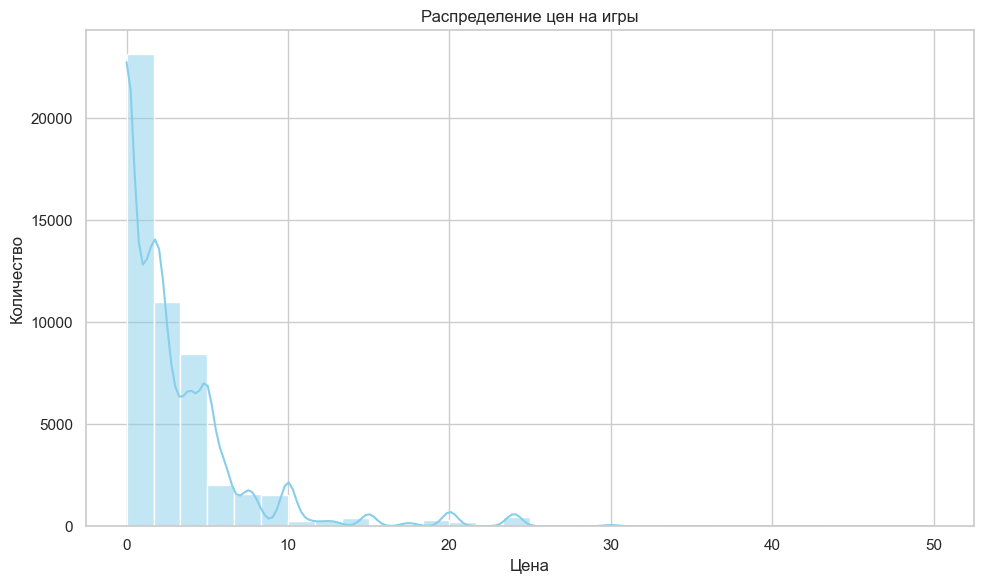

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(cleaned_df['price'], bins=30, kde=True, color='skyblue')
plt.title('Распределение цен на игры')
plt.xlabel('Цена')
plt.ylabel('Количество')
plt.grid(True)
plt.tight_layout()
plt.show()

**Корреляция между количеством покупок и временем игры**

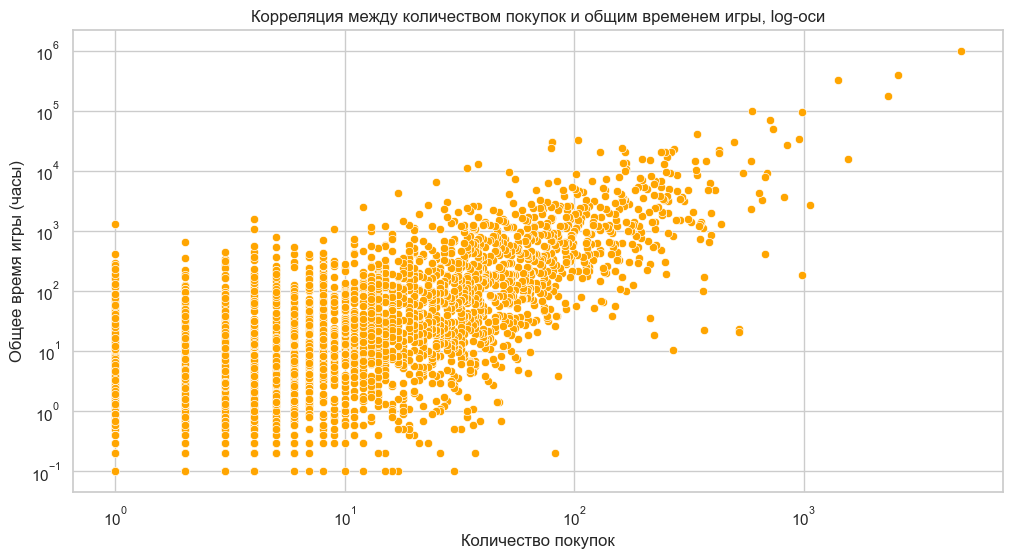

In [ ]:
game_stats = pd.DataFrame({
    'purchases': df[df['purchase'] == 1]['game-title'].value_counts(),
    'total_play_time': df[df['play'] == 1].groupby('game-title')['value'].sum()
}).dropna().sort_values(by='purchases', ascending=False)

plt.figure(figsize=(12, 6))
sns.scatterplot(x='purchases', y='total_play_time', data=game_stats, color='orange')
plt.xscale('log')
plt.yscale('log')
plt.title('Корреляция между количеством покупок и общим временем игры, log-оси')
plt.xlabel('Количество покупок')
plt.ylabel('Общее время игры (часы)')
plt.show()

Видно, что у игр с незначительным количеством скачиваний может быть много часов, т.е. большой коэффициент вовлеченности. Впрочем, это можно списать на небольшой размер датасета.

In [ ]:
print("Описательная статистика времени игры:")
print(df[df['play'] == 1]['value'].describe())

correlation = game_stats['purchases'].corr(game_stats['total_play_time'])
print(f"Коэффициент корреляции между покупками и временем игры: {correlation:.3f}")

Описательная статистика времени игры:
count    72417.000000
mean        51.524097
std        240.361177
min          0.100000
25%          1.000000
50%          4.500000
75%         19.400000
max      11754.000000
Name: value, dtype: float64
Коэффициент корреляции между покупками и временем игры: 0.816


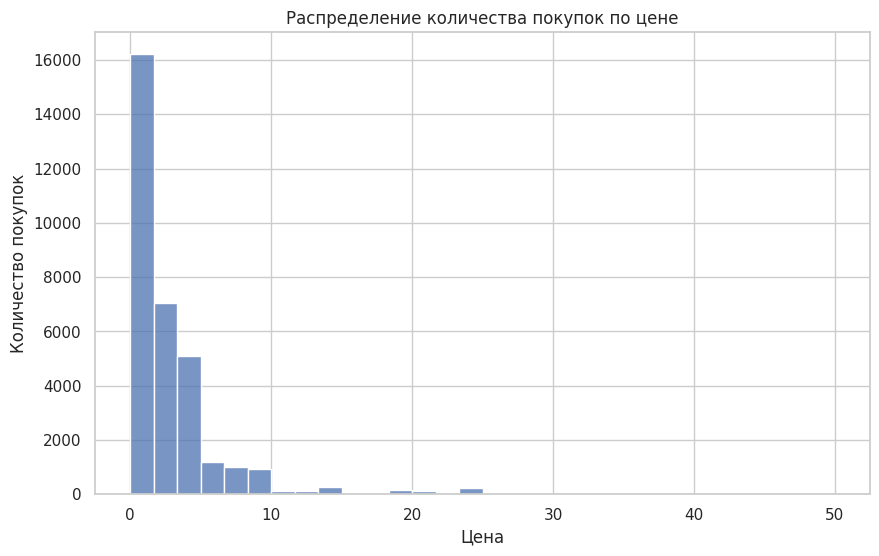

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(data=cleaned_df[cleaned_df['purchase'] == 1], x='price', bins=30, kde=False)

plt.xlabel('Цена')
plt.ylabel('Количество покупок')
plt.title('Распределение количества покупок по цене')
plt.grid(True)
plt.show()

Таким образом, видна обратная корреляция цены с количеством покупок

## Построение предсказательной модели

Построим рекомендательную систему на основе LightGBM. Если отбросить доп признаки, то можно было бы и SVD использовать, но я принял решение сравнить LightGBM для двух датасетов.

LightGBM — это алгоритм градиентного бустинга для работы с табличными данными. Он обрабатывает категориальные признаки без сложного кодирования, что удобно для рекомендательных систем с большим количеством пользователей и игр.

In [ ]:
def prepare_df(df):
    return df.groupby(['user-id', 'game-title']).agg({
        'value': 'mean',
        'price': 'mean',
        'play': 'max',
        'purchase': 'max',
        'publisher': 'first',
        'type': 'first'
    }).reset_index()


def encode_df(df, encoders=None):
    if encoders is None:
        encoders = {
            'user-id': LabelEncoder(),
            'game-title': LabelEncoder(),
            'publisher': LabelEncoder(),
            'type': LabelEncoder(),
        }
    for col in encoders:
        df[col] = encoders[col].fit_transform(df[col])
    return df, encoders


def train_model(X, y):
    model = LGBMRegressor()
    model.fit(X, y)
    return model


def evaluate_recall_at_n(df, use_features=False, N=5, max_users=50):
    df = prepare_df(df)
    users = df['user-id'].unique()
    hits = 0
    total = 0

    for user in tqdm(users[:max_users], desc="Оценка hit rate"):
        user_data = df[df['user-id'] == user]
        if len(user_data) < 2:
            continue

        test_row = user_data.sample(1)
        train_data = df.drop(test_row.index)
        hidden_game = test_row['game-title'].values[0]

        # Подготовка энкодеров
        full_df = pd.concat([train_data, test_row])
        full_df_encoded, encoders = encode_df(full_df)
        train_df = full_df_encoded.drop(index=test_row.index)

        if use_features:
            X_train = train_df.drop(columns='value')
        else:
            X_train = train_df[['user-id', 'game-title']]
        y_train = train_df['value']

        model = train_model(X_train, y_train)

        # Предсказания для всех игр, которые пользователь не играл
        all_games = df['game-title'].unique()
        user_played = df[df['user-id'] == user]['game-title'].unique()
        unseen_games = [g for g in all_games if g not in user_played or g == hidden_game]

        candidate_rows = []
        for game in unseen_games:
            row = {
                'user-id': user,
                'game-title': game,
                'price': df[df['game-title'] == game]['price'].mean(),
                'play': df[df['game-title'] == game]['play'].max(),
                'purchase': df[df['game-title'] == game]['purchase'].max(),
                'publisher': df[df['game-title'] == game]['publisher'].values[0] if not df[df['game-title'] == game].empty else "Unknown",
                'type': df[df['game-title'] == game]['type'].values[0] if not df[df['game-title'] == game].empty else "Игра"
            }
            candidate_rows.append(row)

        candidates_df = pd.DataFrame(candidate_rows)

        # Кодируем те же энкодеры
        for col, le in encoders.items():
            candidates_df[col] = le.transform(candidates_df[col].astype(str))

        if use_features:
            X_candidates = candidates_df.drop(columns='value', errors='ignore')
        else:
            X_candidates = candidates_df[['user-id', 'game-title']]

        preds = model.predict(X_candidates)
        candidates_df['predicted'] = preds

        # Топ-N предсказанных игр
        top_n_games = candidates_df.sort_values(by='predicted', ascending=False).head(N)['game-title'].values

        hidden_game_encoded = encoders['game-title'].transform([hidden_game])[0]
        if hidden_game_encoded in top_n_games:
            hits += 1
        total += 1

    hit_rate = hits / total if total > 0 else 0
    print(f"{'Полная модель' if use_features else 'SVD-подобная'} - Hit Rate@{N}: {hit_rate:.4f}")
    return hit_rate



# === Оценка ===
mae_full_features = evaluate_recall_at_n(cleaned_df.copy(), use_features=True, max_users=50)

Оценка hit rate:   0%|          | 0/50 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000641 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 866
[LightGBM] [Info] Number of data points in the train set: 29245, number of used features: 6
[LightGBM] [Info] Start training from score 8.689756


Оценка hit rate:   2%|▏         | 1/50 [00:20<16:30, 20.20s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000581 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 866
[LightGBM] [Info] Number of data points in the train set: 29245, number of used features: 6
[LightGBM] [Info] Start training from score 8.689756


Оценка hit rate:   4%|▍         | 2/50 [00:40<16:19, 20.41s/it]

...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000625 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 128803, number of used features: 2
[LightGBM] [Info] Start training from score 14.092892


Оценка hit rate:   4%|▍         | 2/50 [07:42<3:05:25, 231.78s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000486 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 128803, number of used features: 2
[LightGBM] [Info] Start training from score 14.092985


Оценка hit rate:   4%|▍         | 2/50 [08:35<3:26:19, 257.91s/it]


KeyboardInterrupt: 

Для улучшенного датасета hitrate получился в 0.1. Это означает, что модель правильно угадала скрытую игру для данного пользователя в топ-N рекомендаций примерно в 10% случаев.

То есть из всех проверенных пользователей (например, 50) только в 5 случаях (10%) скрытая игра оказалась в числе рекомендованных моделей топ-N.

Что это означает? Что данных мало (тут 30000 строк), и они малорелевантны к текущей задаче.

Тем не менее, если игроку предлагать больше игр, то может одна интересная ему и попадется (так, например, и делает Steam с его подборками.)

In [ ]:
mae_svd_like = evaluate_recall_at_n(cleaned_df.copy(), use_features=False, max_users=50)

Оценка hit rate:   0%|          | 0/50 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000195 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 29245, number of used features: 2
[LightGBM] [Info] Start training from score 8.689756


Оценка hit rate:   2%|▏         | 1/50 [00:22<18:10, 22.26s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 29245, number of used features: 2
[LightGBM] [Info] Start training from score 8.689766


Оценка hit rate:   4%|▍         | 2/50 [00:42<17:00, 21.25s/it]

...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000276 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 29245, number of used features: 2
[LightGBM] [Info] Start training from score 8.689756


Оценка hit rate:  98%|█████████▊| 49/50 [17:28<00:20, 20.84s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000322 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 29245, number of used features: 2
[LightGBM] [Info] Start training from score 8.689756


Оценка hit rate: 100%|██████████| 50/50 [17:51<00:00, 21.43s/it]

SVD-подобная - Hit Rate@5: 0.0000


А без доп признаков хитрейт уже 0. Конечно, можно это оправдывать тем, что датасет стал в 7 раз меньше. Но я парирую это тем, что будь он в исходной форме, тренировка заняла бы вечность (х30 время на итерацию).

Таким образом, получили модель с приемлемой точностью. При расширении датасета получим приемлемую рекомендательную систему, которую можно использовать в маркетплейсах для игр.